# Intro to the API

Start with LFADS on a Lorenz dataset with 20 neurons, then run NDT, LangevinFlow,
and CASSM on the same data. Each method trains for 200 epochs.

Open this notebook in Jupyter with LaDyS, NumPy, and Matplotlib installed in the
kernel's Python environment. Run the cells in order from the `tutorials/`
directory. Everything runs on CPU, and no data download is needed.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from ladys import Experiment, ExperimentConfig, PreprocessingConfig
from ladys.datasets import LorenzDatasetConfig
from ladys.models import LFADSConfig
from ladys.training import TrainerConfig

## Configure the experiment

Lorenz dynamics generate firing rates for 20 simulated neurons; Poisson sampling
turns those rates into spike counts. Training and validation use separate trials
of the same underlying trajectories.

`ExperimentConfig` combines the dataset, model, preprocessing, and training
settings. LFADS uses its standard Lorenz model settings, including 20 factors,
and trains on raw spike counts. The seeds fix the data, training randomness,
and evaluation sampling.

In [2]:
config = ExperimentConfig(
    dataset=LorenzDatasetConfig(
        neurons=20,
        num_inits=2,
        num_trials=8,
        num_steps=60,
        seed=0,
    ),
    model=LFADSConfig(),
    preprocessing=PreprocessingConfig(),
    trainer=TrainerConfig(epochs=200, device="cpu", live_eval_interval=20),
    batch_size=4,
    output_dir="runs/lorenz_tutorial",
    run_name="lfads",
    evaluation_seed=0,
)

## Train and evaluate

`Experiment.run()` prepares the data, builds and trains the model, evaluates it
on validation trials, and saves the run. The returned result contains the
learning history, evaluation metrics, and artifact paths.

Every 20 epochs, it also evaluates rate reconstruction on the validation trials.

In [3]:
result = Experiment(config).run()

epoch=1 train_loss=520.182 valid_loss=203.17


epoch=2 train_loss=243.209 valid_loss=7.34623


epoch=3 train_loss=58.9895 valid_loss=-204.877


epoch=4 train_loss=-126.056 valid_loss=-430.725


epoch=5 train_loss=-312.268 valid_loss=-620.486


...

epoch=196 train_loss=-1618.11 valid_loss=-1657.61


epoch=197 train_loss=-1620.36 valid_loss=-1662.68


epoch=198 train_loss=-1622.41 valid_loss=-1663.88


epoch=199 train_loss=-1630.49 valid_loss=-1659.06


epoch=200 train_loss=-1618.28 valid_loss=-1665.98 co_bps=1.16102 latent_linear_r2=0.996216 poisson_nll=-1.40486 rate_mse=0.198176 rate_r2=0.990705


## Plot learning curves

LFADS minimizes an ELBO-based objective that combines spike-count reconstruction
with latent regularization. Lower loss is better; validation evaluates trials
excluded from training.

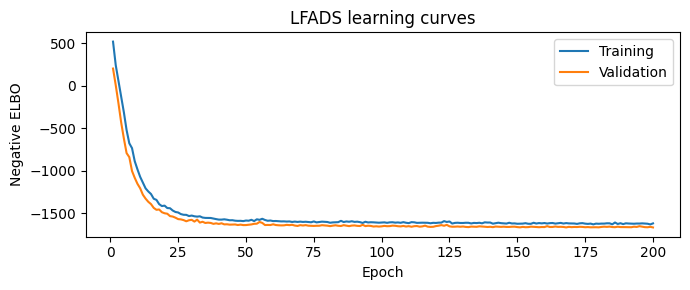

In [4]:
epochs = [report.epoch + 1 for report in result.history]
train_loss = [report.train.loss for report in result.history]
valid_loss = [report.valid.loss for report in result.history]

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(epochs, train_loss, label="Training")
ax.plot(epochs, valid_loss, label="Validation")
ax.set(xlabel="Epoch", ylabel="Negative ELBO", title="LFADS learning curves")
ax.xaxis.get_major_locator().set_params(integer=True)
ax.legend()
fig.tight_layout()
plt.show()

## Inspect reconstructed activity

The saved predictions contain the model's estimated rates and the known Lorenz
rates for the validation trials. Compare them for one neuron in the first
validation trial. Ground-truth rates are used for evaluation, not training.

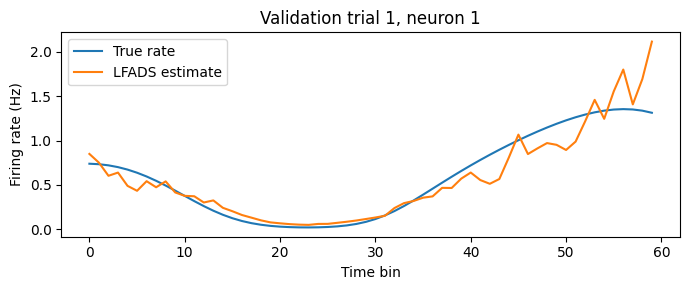

In [5]:
with np.load(result.predictions_path) as predictions:
    true_rates = predictions["target_rates"][0, :, 0]
    predicted_rates = predictions["pred_rates"][0, :, 0]

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(true_rates, label="True rate")
ax.plot(predicted_rates, label="LFADS estimate")
ax.set(xlabel="Time bin", ylabel="Firing rate (Hz)", title="Validation trial 1, neuron 1")
ax.legend()
fig.tight_layout()
plt.show()

## Inspect the results

The run folder includes `config.json`, `history.csv`, `metrics.json`,
`model.pt`, and `predictions.npz`. The metrics below include rate reconstruction
error and latent reconstruction quality.

In [6]:
print(f"Run saved to: {result.run_dir}")
result.metrics

Run saved to: runs/lorenz_tutorial/lfads-2


{'co_bps': 1.1610225439071655,
 'poisson_nll': -1.4048558473587036,
 'rate_mse': 0.1981763243675232,
 'rate_r2': 0.9907048344612122,
 'latent_linear_r2': 0.9962155509799101}

## Run NDT, LangevinFlow, and CASSM

Load each method's [Lorenz recipe](../configs/experiment/synthetic/lorenz), then
reuse our 20-neuron dataset and 200-epoch training budget. This preserves each
method's architecture, optimizer, and preprocessing.

CASSM's recipe applies Gaussian smoothing to its input spike counts
(`smooth_firing_rate`, `kern_sd_ms=50`, `sampling_precision=20`) and uses a
20-dimensional projection. The other methods train on raw spike counts.
LangevinFlow uses its recipe's 50-sample prediction averaging. These settings
are loaded below, rather than copied into the notebook.

In [7]:
from dataclasses import replace
from pathlib import Path

from ladys import load_experiment_config

recipe_root = Path("../configs/experiment/synthetic/lorenz")
methods = {"NDT": "ndt", "LangevinFlow": "langevin_flow", "CASSM": "cassm"}
comparison_configs = {
    name: replace(
        load_experiment_config(recipe_root / method / f"{method}_lorenz.yaml"),
        dataset=config.dataset,
        trainer=config.trainer,
        batch_size=config.batch_size,
        evaluation_seed=config.evaluation_seed,
        output_dir=str(result.run_dir / "comparison"),
        run_name=method,
    )
    for name, method in methods.items()
}

In [8]:
comparison_results = {
    name: Experiment(model_config).run()
    for name, model_config in comparison_configs.items()
}

epoch=1 train_loss=1.07235 valid_loss=0.765869


epoch=2 train_loss=0.765507 valid_loss=0.567211


epoch=3 train_loss=0.503341 valid_loss=0.430627


epoch=4 train_loss=0.46606 valid_loss=0.334324


epoch=5 train_loss=0.504563 valid_loss=0.250553


...

epoch=196 train_loss=0.153646 valid_loss=0.188094


epoch=197 train_loss=0.160061 valid_loss=0.190452


epoch=198 train_loss=0.16221 valid_loss=0.189499


epoch=199 train_loss=0.156536 valid_loss=0.180197


epoch=200 train_loss=0.152397 valid_loss=0.177863 co_bps=1.21034 latent_linear_r2=0.993005 poisson_nll=-1.47664 rate_mse=1.06503 rate_r2=0.950046


## Inspect the three runs

Each model has its own loss definition and scale. For LangevinFlow, the training
objective includes a ramped KL penalty, while validation reports reconstruction
loss alone; we separate those terms below. All rate traces use the same
validation trial and neuron as the LFADS plot, with no smoothing added to the
saved predictions for plotting.

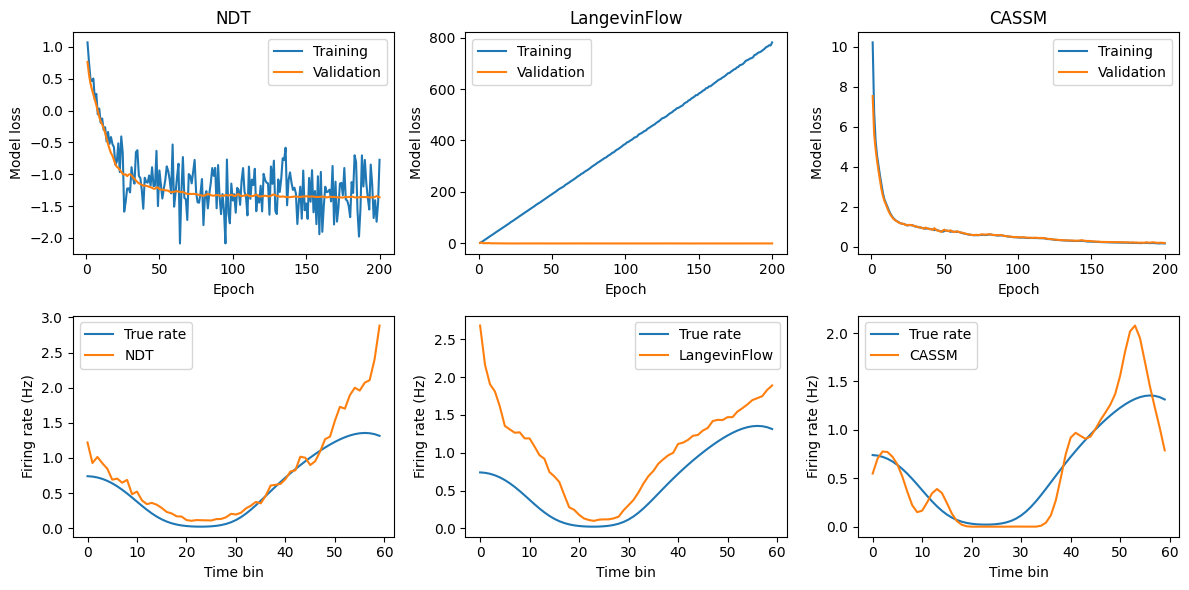

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for column, (name, model_result) in enumerate(comparison_results.items()):
    history = model_result.history
    epochs = [report.epoch + 1 for report in history]
    ax = axes[0, column]
    ax.plot(epochs, [report.train.loss for report in history], label="Training")
    ax.plot(epochs, [report.valid.loss for report in history], label="Validation")
    ax.set(title=name, xlabel="Epoch", ylabel="Model loss")
    ax.xaxis.get_major_locator().set_params(integer=True)
    ax.legend()

    with np.load(model_result.predictions_path) as predictions:
        ax = axes[1, column]
        ax.plot(predictions["target_rates"][0, :, 0], label="True rate")
        ax.plot(predictions["pred_rates"][0, :, 0], label=name)
    ax.set(xlabel="Time bin", ylabel="Firing rate (Hz)")
    ax.legend()

fig.tight_layout()
plt.show()

## Understand LangevinFlow's loss

LangevinFlow trains on `reconstruction_nll + kl_weight * kl`. Its recipe ramps
the KL weight over 500 epochs, so the total objective can rise while spike-count
reconstruction improves. The left panel shows the total and weighted KL penalty;
the right panel compares reconstruction losses. At 200 epochs, this warmup is
still in progress; the full Lorenz recipe normally trains for 1,000 epochs.

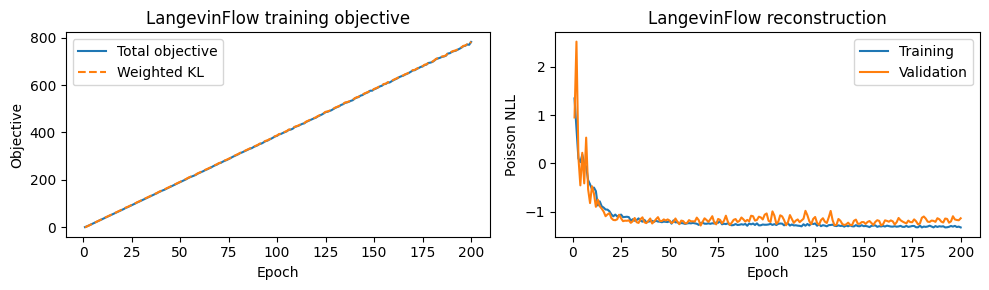

In [10]:
history = comparison_results["LangevinFlow"].history
lf_epochs = [report.epoch + 1 for report in history]
weighted_kl = [report.train.metrics["kl_weight"] * report.train.metrics["kl"] for report in history]

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(lf_epochs, [report.train.loss for report in history], label="Total objective")
axes[0].plot(lf_epochs, weighted_kl, linestyle="--", label="Weighted KL")
axes[0].set(xlabel="Epoch", ylabel="Objective", title="LangevinFlow training objective")
axes[1].plot(lf_epochs, [report.train.metrics["reconstruction_nll"] for report in history], label="Training")
axes[1].plot(lf_epochs, [report.valid.metrics["reconstruction_nll"] for report in history], label="Validation")
axes[1].set(xlabel="Epoch", ylabel="Poisson NLL", title="LangevinFlow reconstruction")
for ax in axes:
    ax.legend()
fig.tight_layout()
plt.show()

## Compare rate reconstruction

Rate mean squared error (MSE) provides a common metric across methods. These
values average over every validation trial, time bin, and neuron; lower is better.
The curve shows the fresh validation evaluations collected every 20 epochs.

In [11]:
all_results = {"LFADS": result, **comparison_results}
for name, model_result in all_results.items():
    print(f"{name:14s} rate MSE: {model_result.metrics['rate_mse']:.3f}")

LFADS          rate MSE: 0.198
NDT            rate MSE: 0.508
LangevinFlow   rate MSE: 5.366
CASSM          rate MSE: 1.065


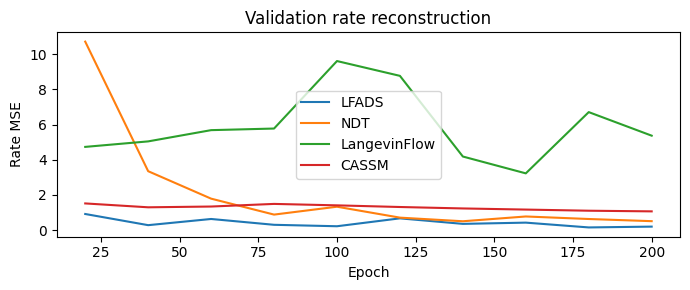

In [12]:
fig, ax = plt.subplots(figsize=(7, 3))
for name, model_result in all_results.items():
    evaluations = [report for report in model_result.history if "eval/rate_mse" in report.metrics]
    ax.plot(
        [report.epoch + 1 for report in evaluations],
        [report.metrics["eval/rate_mse"] for report in evaluations],
        label=name,
    )
ax.set(xlabel="Epoch", ylabel="Rate MSE", title="Validation rate reconstruction")
ax.legend()
fig.tight_layout()
plt.show()

## Reproduce the three runs with one command

The CLI accepts several YAML recipes or saved `config.json` files in one
invocation and runs them sequentially. The command below uses the exact
configurations saved by the three comparison runs, including the 20-neuron
dataset and each model's settings.

After executing the cells above, run the printed command from the notebook's
directory to train on a CUDA GPU. Use
`--device cpu` to run on CPU.

In [13]:
config_paths = " ".join(str(run.config_path) for run in comparison_results.values())
print(f"ladys run -c {config_paths} --device cuda")

ladys run -c runs/lorenz_tutorial/lfads-2/comparison/ndt/config.json runs/lorenz_tutorial/lfads-2/comparison/langevin_flow/config.json runs/lorenz_tutorial/lfads-2/comparison/cassm/config.json --device cuda


Try changing the LFADS factor count, a model's size, or the training budget and
rerun from the relevant configuration cell. For other models and configuration
options, see the [LaDyS documentation](https://zkunkworks.com/ladys/).